# 06 · Extending and shipping

Every program you wrote so far used vocabulary somebody else had registered. Part 6 adds to it, and then ships what it added.

Three registries accept new classes. A **waveform** is a pulse shape, a **sweep source** is a sweep axis, and a **vendor namespace** carries operations the core will never have. Each one is a Python class, or two, plus the registration calls that put it in the language, one for a sweep source, two for a waveform, and four for a vendor operation.

- write all three, live in this notebook
- watch the `require` line appear in the file, and a rack that lacks the token refuse the program
- ship them as a package, so a `require` line loads the extension a file needs
- diff two calibration runs, and run the checker from a shell
- close with the whole bring-up as one script, a file per step and a table of measured against true

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
# Section 6.6 loads a file that requires the qblox vendor, and the point of that cell is the import
# happening on demand, so probe for the distributions rather than importing them here.
from importlib.util import find_spec

if find_spec("qprogram") is None or find_spec("qprogram_qblox") is None:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "qprogram[viz]==0.1.0", "qprogram-qblox==0.1.0", "qprogram-qdac==0.1.0", "scipy",
        ],
        check=True,
    )

from importlib.metadata import version

print("qprogram", version("qprogram"))
print("qprogram-qblox", version("qprogram-qblox"), "· qprogram-qdac", version("qprogram-qdac"))

qprogram 0.1.0
qprogram-qblox 0.1.0 · qprogram-qdac 0.1.0


In [2]:
import difflib
import json
import subprocess
import sys
import tempfile
from dataclasses import replace
from importlib.metadata import entry_points
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations import Play
from qprogram.operations.operation import Operation
from qprogram.plotting import LIGHT, Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square, Waveform

print("imports ready")

imports ready


## 6.0 The device

The same simulated chip as Parts 1 to 4, and the numbers to be recovered from nothing but simulated data, the three `cz_*` in 6.4 and the rest in the capstone in 6.9.

The schema is `BusSchema.flux_tunable_transmon()`, Part 3's, so `q[0]` carries a `flux` bus beside the drive and readout pair.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "cz_g": 6.0e6,  # Hz, coupling to the neighbour
    "cz_amp_res": 0.42,  # flux amplitude that brings the pair into resonance
    "cz_slope": 1.2e9,  # Hz per unit flux amplitude
}

schema = BusSchema.flux_tunable_transmon()
q = schema.q

print("buses on this chip:", [q[0].drive, q[0].readout, q[0].flux])

buses on this chip: ['q0/drive', 'q0/readout', 'q0/flux']


## 6.1 A custom waveform

A `Waveform` subclass owes two methods. `envelope(resolution)` returns the samples, one per `resolution` nanoseconds, and `get_duration()` returns the length in nanoseconds. Nothing else is required, and nothing else in the class below is QProgram.

`HalfSine` is one half period of a sine, a shape the core does not ship.

In [4]:
class HalfSine(Waveform):
    """One half period of a sine, from zero up to the amplitude and back to zero."""

    def __init__(self, amplitude: float, duration: int) -> None:
        self.amplitude, self.duration = amplitude, duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        n = self.duration // resolution
        return self.amplitude * np.sin(np.pi * np.arange(n) / n)

    def get_duration(self) -> int:
        return self.duration


flux_pulse = HalfSine(amplitude=0.42, duration=40)

print("duration:", flux_pulse.get_duration(), "ns")
print("first four samples:", flux_pulse.envelope()[:4].round(4))

duration: 40 ns
first four samples: [0.     0.033  0.0657 0.098 ]


One call draws it.

<Axes: title={'left': 'HalfSine'}, xlabel='Time (ns)', ylabel='Amplitude'>

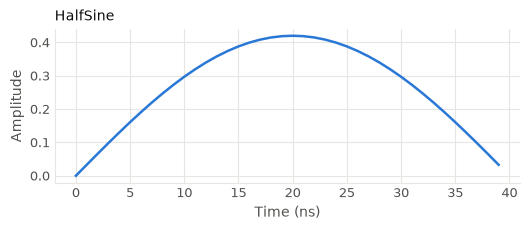

In [5]:
flux_pulse.plot()

None of what the next cell prints is written in the class. It comes off `Waveform`, which derives every one of them from the two methods you wrote.

In [6]:
print("written on HalfSine:  ", sorted(name for name in vars(HalfSine) if not name.startswith("_")))
print("inherited from Waveform:",
      [name for name in ("plot", "area", "peak_amplitude", "rms_amplitude", "spectrum")
       if name not in vars(HalfSine)])
print(f"area {flux_pulse.area():.3f}, peak amplitude {flux_pulse.peak_amplitude():.3f}")
print("two built the same way compare equal:", HalfSine(0.42, 40) == HalfSine(0.42, 40))

written on HalfSine:   ['envelope', 'get_duration']
inherited from Waveform: ['plot', 'area', 'peak_amplitude', 'rms_amplitude', 'spectrum']
area 10.673, peak amplitude 0.420
two built the same way compare equal: True


Part 3 drew one pulse over another by handing the `Axes` that came back to a second call as `target=`, and a class you wrote is no different.

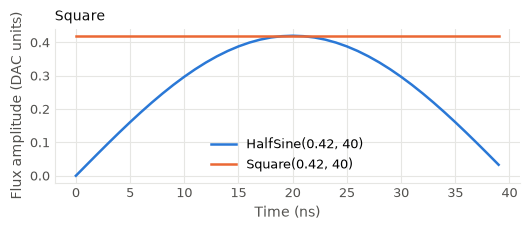

In [7]:
ax = flux_pulse.plot()
rotated = Style(theme=replace(LIGHT, series=LIGHT.series[1:] + LIGHT.series[:1]))
Square(amplitude=0.42, duration=40).plot(target=ax, style=rotated)
for line, name in zip(ax.lines, ("HalfSine(0.42, 40)", "Square(0.42, 40)"), strict=True):
    line.set_label(name)
ax.set_ylabel("Flux amplitude (DAC units)")
ax.legend(frameon=False, fontsize=9)

### A parameter a sweep can bind

Put a variable in the amplitude position and it does not arrive as a number. It arrives as a `qp.Expression`, and the multiplication inside `envelope` meets that instead of a float.

In [8]:
probe = qp.QProgram(label="probe", schema=schema)
probe_amp = probe.variable("flux_amp", label="Flux amplitude", units="DAC units")

try:
    HalfSine(amplitude=probe_amp, duration=40).envelope()
except TypeError as error:
    print("TypeError:", error)

TypeError: Cannot use ndarray in an Expression; expected Expression, handle.<field>, int, or float


Two lines answer it. Annotate the parameter `float | qp.Expression`, and resolve it with `evaluate_or_raise()` at the point of use, which hands back whatever the enclosing sweep has bound. Every shape the core ships is written this way.

Leave the pair out and nothing complains until a platform calls `envelope()`, and the failure is the `TypeError` above, raised out of the expression layer with a message that names neither the waveform nor the variable.

The class below is the one the rest of the notebook uses, the same class with those two changes made.

In [9]:
class HalfSine(Waveform):
    """One half period of a sine, with an amplitude a sweep may bind."""

    def __init__(self, amplitude: float | qp.Expression, duration: int) -> None:
        self.amplitude, self.duration = amplitude, duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        amplitude = self.amplitude
        if isinstance(amplitude, qp.Expression):  # bound by the sweep this pulse sits in
            amplitude = amplitude.evaluate_or_raise()
        n = self.duration // resolution
        return amplitude * np.sin(np.pi * np.arange(n) / n)

    def get_duration(self) -> int:
        return self.duration


print("still a Waveform, so still plots:", callable(HalfSine(0.42, 40).plot))

still a Waveform, so still plots: True


### Registering it

The class is a working Python object already. Two calls put it in the language.

`qp.register_waveform` adds it to the serialization registry under its class name, so `qp.dumps` writes the constructor and `qp.loads` builds one back. The writer emits the object's public attributes and the parser rebuilds it through `__init__`, and that pairing costs the one constraint the whole seam rests on. The constructor arguments have to *be* the object's state. Store a parameter under a different attribute name, or compute state the constructor cannot reproduce, and the round trip breaks with no warning.

`qp.register_waveform_token` maps the class to a capability token, so a rack that cannot generate the shape has a name to refuse it by. `register_waveform` hands the class straight back, which is why the spelling `@qp.register_waveform` above a class definition works too, and the token call takes a token as well so it stays an ordinary statement.

Every registry in this part is global and keyed by name, so a registering cell runs once. Re-running one after editing its class raises a collision error, because the name is taken by the class you just replaced, and the way out is to restart the kernel.

In [10]:
qp.register_waveform(HalfSine)
qp.register_waveform_token(HalfSine, "waveform.half_sine")

one_pulse = qp.QProgram(label="one_pulse", schema=schema)
one_pulse.play(q[0].flux, HalfSine(amplitude=0.42, duration=40))

print("body:" + qp.dumps(one_pulse).split("body:", 1)[1].rstrip())
print("round-trips:", qp.loads(qp.dumps(one_pulse)).body == one_pulse.body)
print("the play asks for:", sorted(Play(q[0].flux, HalfSine(0.42, 40)).required_capabilities()))

body:
  play q[0].flux HalfSine(amplitude=0.42, duration=40)
round-trips: True
the play asks for: ['op.play', 'waveform.half_sine', 'waveform.single']


## 6.2 A custom sweep source

A sweep source is the second argument of `program.sweep`, and Part 2 used the ones the core ships. A subclass declares `KIND` and `TOKEN`, implements `length()` and `values()`, and keeps its parameters as public attributes so the text form derives itself the way the waveform's did.

`Chevron` takes a centre, a span, and a number of points, the way a symmetric scan gets written down in the first place.

In [11]:
class Chevron(qp.SweepSource):
    """`num` points spanning `span`, centred on `center`."""

    KIND = "arbitrary"
    TOKEN = "sweep.chevron"

    def __init__(self, center: float, span: float, num: int) -> None:
        self.center, self.span, self.num = center, span, num

    def length(self) -> int:
        return self.num

    def values(self):
        return np.linspace(self.center - self.span / 2, self.center + self.span / 2, self.num)


scan = Chevron(center=0.42, span=0.20, num=21)

print("length:", scan.length(), "· kind:", scan.KIND)
print("values:", scan.values().round(3))

length: 21 · kind: arbitrary
values: [0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45
 0.46 0.47 0.48 0.49 0.5  0.51 0.52]


`qp.register_sweep_source` adds the class to the serialization registry under its name, and it puts the class's `TOKEN` in the capability registry too, where the waveform needed a second call for that. `tokens()` is the other thing a platform reads off a source.

In [12]:
qp.register_sweep_source(Chevron)

print("tokens it asks a platform for:", sorted(scan.tokens()))
print("wrapped in Rotate:      ", sorted(qp.Rotate(scan, 5).tokens()))

tokens it asks a platform for: ['sweep.arbitrary', 'sweep.chevron']
wrapped in Rotate:       ['sweep.arbitrary', 'sweep.chevron', 'sweep.rotate']


Two came back, the `TOKEN` the class declared and the `sweep.arbitrary` that `KIND` implies. A combinator unions its child's tokens with its own, so a rack missing `sweep.chevron` refuses the rotated chevron too.

The source goes anywhere `qp.Linspace` goes, and the amplitude inside the loop below is the `Expression` the two lines added in 6.1 are there to resolve, on the day a compiler samples the envelope.

In [13]:
scan_program = qp.QProgram(label="chevron_scan", schema=schema)
scan_amp = scan_program.variable("flux_amp", label="Flux amplitude", units="DAC units")

with scan_program.sweep(scan_amp, Chevron(center=0.42, span=0.20, num=21)):
    scan_program.play(q[0].flux, HalfSine(amplitude=scan_amp, duration=40))

print("body:" + qp.dumps(scan_program).split("body:", 1)[1].rstrip())
print("round-trips:", qp.loads(qp.dumps(scan_program)).body == scan_program.body)

body:
  var flux_amp label="Flux amplitude" units="DAC units"

  for flux_amp in Chevron(center=0.42, span=0.2, num=21):
    play q[0].flux HalfSine(amplitude=flux_amp, duration=40)
round-trips: True


## 6.3 A vendor namespace

A vendor namespace is two classes. An `Operation` subclass is the node that lands in the tree, and it answers `required_capabilities()` with a token under its own vendor prefix. A `VendorNamespace` subclass is the method surface, where `self._append` puts a node into the program being built.

The two seams above add vocabulary the core could plausibly have shipped, and this one is for vocabulary it must never ship. The operation below sets a programmable room-temperature attenuator on a drive line, one box in one rack, which belongs in nobody's vendor-agnostic DSL.

In [14]:
class SetAttenuation(Operation):
    """Set the room-temperature attenuator on a drive line, in dB."""

    def __init__(self, bus: str, db: float) -> None:
        self.bus, self.db = bus, db

    def required_capabilities(self) -> set[str]:
        return {"vendor.fridge.set_attenuation"}


class FridgeNamespace(qp.VendorNamespace):
    def set_attenuation(self, bus: str, db: float) -> None:
        self._append(SetAttenuation(bus=bus, db=db))


print("SetAttenuation asks for:", SetAttenuation(q[0].drive, 20.0).required_capabilities())

SetAttenuation asks for: {'vendor.fridge.set_attenuation'}


Four registration calls put the pair in the language, and their names say what they do. One needs a note. `register_vendor_operation` teaches the writer and the parser, and the default parser reads your `__init__` signature, the same derivation the waveform leaned on.

The printout below is the sum of the four. `program.fridge` resolves on an ordinary `QProgram`, the operation writes itself into the body, and the file grew a `require fridge 0.1` line under the header.

In [15]:
qp.QProgram.register_vendor("fridge", FridgeNamespace)
qp.register_vendor_version("fridge", "0.1.0")
qp.register_vendor_operation("fridge", "set_attenuation", SetAttenuation)
qp.register_capability_tokens("vendor.fridge.set_attenuation")

warm_up = qp.QProgram(label="warm_up", schema=schema)
warm_up.fridge.set_attenuation(q[0].drive, 20.0)

print(qp.dumps(warm_up))

#!QProgram 1.0

require fridge 0.1

metadata:
  label: "warm_up"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  fridge.set_attenuation q[0].drive 20.0



## 6.4 All three in one program

The program attenuates the drive line, then steps the flux amplitude and reads the qubit out. The vendor operation, the custom sweep source, and the custom waveform each appear in the text.

In [16]:
program = qp.QProgram(label="cz_chevron", description="flux-activated swap on the fridge rack", schema=schema)
flux_amp = program.variable("flux_amp", label="Flux amplitude", units="DAC units")

program.fridge.set_attenuation(q[0].drive, 20.0)
with program.average(shots=200):
    with program.sweep(flux_amp, Chevron(center=0.42, span=0.20, num=21)):
        program.play(q[0].flux, HalfSine(amplitude=flux_amp, duration=40))
        program.sync()
        swap = program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

text = qp.dumps(program)
print(text)
print("round-trips:", qp.loads(text).body == program.body)
print("diagnostics from the reference platform:", qp.validate(program, qp.reference_capabilities())[0])

#!QProgram 1.0

require fridge 0.1

metadata:
  label: "cz_chevron"
  description: "flux-activated swap on the fridge rack"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var flux_amp label="Flux amplitude" units="DAC units"

  fridge.set_attenuation q[0].drive 20.0
  average 200:
    for flux_amp in Chevron(center=0.42, span=0.2, num=21):
      play q[0].flux HalfSine(amplitude=flux_amp, duration=40)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]

round-trips: True
diagnostics from the reference platform: []


The `require` line is the contract, and 6.6 is where a lab without the extension installed finds out.

The round trip needed no help from you. Each of the three is registered under its class name and serialized from its constructor signature, so the parser rebuilds all three off the text alone. The reference platform accepts every token in the registry, so the program validates and runs.

<Axes: xlabel='Flux amplitude (DAC units)', ylabel='State'>

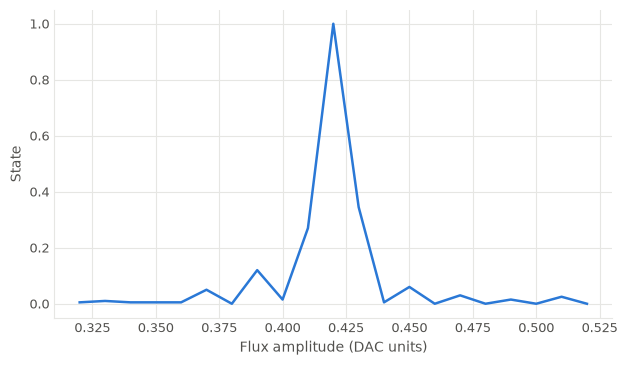

In [17]:
def p_swap(bus, env):
    """Stand-in for the fridge: the pair exchanges its excitation near cz_amp_res."""
    delta = (env["flux_amp"] - DEVICE["cz_amp_res"]) * DEVICE["cz_slope"]
    omega = np.sqrt((2 * DEVICE["cz_g"]) ** 2 + delta**2)
    contrast = (2 * DEVICE["cz_g"]) ** 2 / omega**2
    return contrast * np.sin(np.pi * omega * 40 * 1e-9) ** 2


chevron_run = qp.simulate(program, model=qp.MockMeasurementModel(p_excited=p_swap, seed=21))
chevron_run.plot(swap, field=MF.STATE)

The x axis reads `Flux amplitude (DAC units)` because `flux_amp` was declared with a label and a unit, and the positions along it are the numbers `Chevron.values()` produced. Nothing else about that call named an axis.

The model's own resonance goes on the axes that came back, beside a marker at every sample.

the scan peaks at 0.420, the model put resonance at 0.420


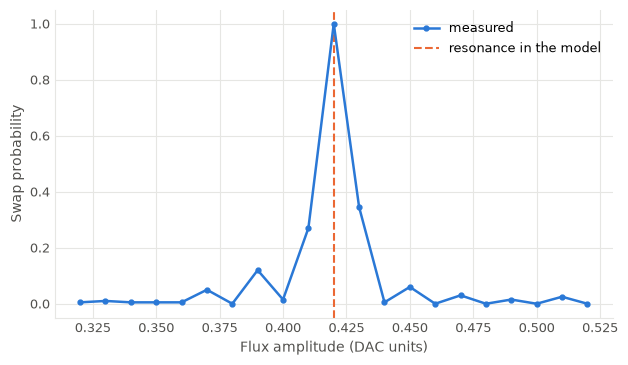

In [18]:
data = chevron_run.get(swap, field=MF.STATE)
amps = data.coords["flux_amp"].values

ax = chevron_run.plot(swap, field=MF.STATE, value=Quantity("Swap probability"), style=Style(markers=True))
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["cz_amp_res"], linestyle="--", color=LIGHT.series[1], label="resonance in the model")
ax.legend(frameon=False, fontsize=9)

print(f"the scan peaks at {amps[data.values.argmax()]:.3f}, the model put resonance at {DEVICE['cz_amp_res']:.3f}")

## 6.5 A rack that refuses it

Registering a token does not put the box in every rack. Part 5 wrote a descriptor down by subtracting one token from the live registry, and the same subtraction takes our attenuator away again.

In [19]:
from qprogram.protocol import CAPABILITY_REGISTRY

no_fridge = frozenset(CAPABILITY_REGISTRY) - {"vendor.fridge.set_attenuation"}
everything_else = qp.CompilerCapabilities(
    profile="no-fridge", version=(0, 1, 0), capabilities=no_fridge, limits={}, predicates=(), vendor_versions={}
)
plain_rack = qp.BusCapabilities(rt=everything_else, host=everything_else)
caps = qp.PlatformCapabilities(bus={}, platform=plain_rack, default_bus_profile=plain_rack)

for d in qp.validate(program, caps)[0]:
    print(f"[{d.severity}] {d.code}: {d.message}")
    print("  at path:", qp.format_path(d.path))
print()
print(qp.explain(program, caps))

[error] missing-capability: 'SetAttenuation' requires capability 'vendor.fridge.set_attenuation' which is not supported by 'no-fridge' (rt) / 'no-fridge' (host)
  at path: body[0]

plan for 'cz_chevron' — errors: 1 · warnings: 0 · info: 0
body
├─ fridge.set_attenuation q[0].drive 20.0                                                [--]       !! missing-capability: 'SetAttenuation' requires capability 'vendor.fridge.set_attenuation' which is not supported by 'no-fridge' (rt) / 'no-fridge' (host)
└─ average 200:                                                                          [rt|host]
   └─ for flux_amp in Chevron(center=0.42, span=0.2, num=21):                            [rt|host]
      ├─ play q[0].flux HalfSine(amplitude=flux_amp, duration=40)                        [rt|host]
      ├─ sync                                                                            [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]


The missing capability comes back by name, with the path to the node that wanted it, before anything is uploaded and while the file stays legal QProgram everywhere else.

### Publishing a profile

"Everything the installed language knows about, minus one" describes no real machine, and it changes every time somebody installs a package. A shipped extension publishes a `qp.Profile` instead, the named and versioned bundle Part 5 reached by name with `CompilerCapabilities.from_profile`.

A name, a version, an `extends`, and a token set are the four fields it asks for, and the smallest useful profile names a parent and adds a single token. `extends` makes the child accumulate the parent's capabilities and predicates while overriding its limits and vendor versions. `qprogram-base-v1` is the core bundle Part 5 resolved by name, so a platform profile that needs one more sweep shape declares only the difference.

In [20]:
FRIDGE_PLATFORM_V1 = qp.Profile(
    name="fridge-platform-v1",
    version=(0, 1, 0),
    extends="qprogram-base-v1",  # the core bundle, plus the one sweep shape we registered above
    capabilities=frozenset({"sweep.chevron"}),
)

qp.register_profile(FRIDGE_PLATFORM_V1)
platform_half = qp.CompilerCapabilities.from_profile("fridge-platform-v1")

print("qprogram-base-v1   ->", len(qp.CompilerCapabilities.from_profile("qprogram-base-v1").capabilities), "tokens")
print("fridge-platform-v1 ->", len(platform_half.capabilities), "tokens, the parent plus sweep.chevron")

qprogram-base-v1   -> 33 tokens
fridge-platform-v1 -> 34 tokens, the parent plus sweep.chevron


The bus half carries the operations, so it lists them rather than inheriting them, and it fills in two of the three fields the first profile left at their defaults. Registration is idempotent for an equal `Profile`, so a re-run is safe.

In [21]:
FRIDGE_BUS_V1 = qp.Profile(
    name="fridge-bus-v1",
    version=(0, 1, 0),
    extends=None,
    capabilities=frozenset(t for t in CAPABILITY_REGISTRY if t.startswith(("op.", "waveform.", "measure.")))
    | {"vendor.fridge.set_attenuation"},
    limits={"min_wait_duration_ns": 4},
    vendor_versions={"fridge": (0, 1, 0)},
)

qp.register_profile(FRIDGE_BUS_V1)
qp.register_profile(FRIDGE_BUS_V1)  # idempotent for an equal profile, so a re-run is safe
bus_half = qp.CompilerCapabilities.from_profile("fridge-bus-v1")

print("fridge-bus-v1      ->", len(bus_half.capabilities), "tokens")

fridge_rack = qp.PlatformCapabilities(
    bus={},
    platform=qp.BusCapabilities(rt=platform_half, host=platform_half),
    default_bus_profile=qp.BusCapabilities(rt=bus_half, host=bus_half),
)
print("\ndiagnostics from the rack we just published:", qp.validate(program, fridge_rack)[0])

fridge-bus-v1      -> 36 tokens

diagnostics from the rack we just published: []


## 6.6 Shipping an extension

Everything above lived in a notebook cell. A shipped extension is a separate Python package that depends on `qprogram` and makes the same registration calls at import time. Two are published, each in a repository of its own, and Part 5 used both. `qprogram-qblox` adds six operations, four of them sequencer instructions and two of them host-side parameter writes that a platform realizes as slow-control settings. `qprogram-qdac` adds four, and its profile is what rack C of Part 5 was reaching for, with no `op.set_offset` in it and a vendor operation in its place. The empty real-time half was Part 5's own claim about the slot, since a package publishes profiles and never slots.

### Entry points

A package takes one step a cell cannot. It declares an entry point:

```toml
[project.entry-points."qprogram.vendors"]
qblox = "qprogram_qblox"
```

Now `loads()` activates the extension on demand, and an archived file stays usable because of it. The file names the extensions it needs in its own header, and a fresh interpreter finds and loads them without the reader knowing what to import.

Watch the namespace list cross the load below. Nothing here has imported `qprogram_qblox`, so `qblox` is absent before the call and present after it.

In [22]:
installed = {ep.name: ep.value for ep in entry_points(group="qprogram.vendors")}
print("vendor entry points installed in this environment:", installed or "none")
print("vendor namespaces registered before the load:", sorted(qp.QProgram._vendor_registry))

needs_qblox = '#!QProgram 1.0\n\nrequire qblox 0.1\n\nbody:\n  qblox.acquire "readout" "weights" name="m0"\n'
loaded = qp.loads(needs_qblox)

print("vendor namespaces registered after the load: ", sorted(qp.QProgram._vendor_registry))
print("the operation it rebuilt:", type(loaded.body.elements[0]).__name__,
      "from", version("qprogram-qblox"))

vendor entry points installed in this environment: {'qblox': 'qprogram_qblox', 'qdac': 'qprogram_qdac'}
vendor namespaces registered before the load: ['fridge']
vendor namespaces registered after the load:  ['fridge', 'qblox']
the operation it rebuilt: Acquire from 0.1.0


Two ways for that to fail, and both name the problem rather than dropping an operation on the floor.

A vendor nobody claims has no entry point to find. Version compatibility is checked at major.minor, where the file's major must equal the installed extension's major and its minor must be less than or equal to the installed minor. Patch is informational, and the writer truncates it. The asymmetry is deliberate. A file written against an older minor loads under a newer extension, because a minor bump adds vocabulary rather than removing it, and a file written against a newer one does not, because the operation it needs may not exist yet.

In [23]:
print("auto-activation of a vendor nobody claims:", qp.try_activate_vendor("acme_rack"))

for label, text in (
    ("a vendor nobody claims", 'require acme_rack 0.1\n\nbody:\n  wait "drive" 100\n'),
    ("a minor this install is too old for", 'require qdac 0.9\n\nbody:\n  wait "drive" 100\n'),
):
    try:
        qp.loads("#!QProgram 1.0\n\n" + text)
    except qp.ParseError as error:
        print(f"\n{label}:")
        print(" ", error)

auto-activation of a vendor nobody claims: False

a vendor nobody claims:
  Line 3: file requires vendor 'acme_rack' 0.1 but no matching extension is registered in this environment — install the package that declares the 'qprogram.vendors' entry point for 'acme_rack', or import the extension before loading

a minor this install is too old for:
  Line 3: file requires qdac 0.9 or compatible; installed qdac is 0.1.0 — minor version too old


### 🧩 Exercise 6.1

Add a vendor measurement field, then prove it is legal on one rack and rejected on another.

The measurement field vocabulary extends through the same registry as everything else, so a readout that returns counts rather than an IQ point needs no new seam.

1. Register the token `measure.fields.counts`.
2. Build a small program that measures with `fields=("counts", MF.STATE)` and print the body of its `.qp` text.
3. Validate it against `qp.reference_capabilities()` and show there are no diagnostics.
4. Validate it against a profile that lacks the token and print the error.
5. Run it, read the `counts` field back, and explain in a comment why it is zero.

In [24]:
qp.register_capability_tokens("measure.fields.counts")

counting = qp.QProgram(label="photon_counting", schema=schema)
with counting.average(shots=8):
    clicks = counting.measure(q[0].readout, "readout", "weights", fields=("counts", MF.STATE))
print("body:" + qp.dumps(counting).split("body:", 1)[1].rstrip())

print("\nreference platform:", qp.validate(counting, qp.reference_capabilities())[0])

no_counts = frozenset(CAPABILITY_REGISTRY) - {"measure.fields.counts"}
strict = qp.CompilerCapabilities(
    profile="iq-only", version=(0, 1, 0), capabilities=no_counts, limits={}, predicates=(), vendor_versions={}
)
strict_bus = qp.BusCapabilities(rt=strict, host=strict)
strict_caps = qp.PlatformCapabilities(bus={}, platform=strict_bus, default_bus_profile=strict_bus)
for d in qp.validate(counting, strict_caps)[0]:
    print("iq-only rack:", d.code, "-", d.message)

counted = qp.simulate(counting, model=qp.MockMeasurementModel(p_excited=lambda bus, env: 0.3, seed=5))
# The token makes the field legal and the executor allocates the array, but the reference platform
# has no idea how to produce counts, so it leaves them at zero. A real compiler is what fills it in.
print("counts:", counted.get(clicks, field="counts").values)
print("state: ", counted.get(clicks, field=MF.STATE).values)

body:
  average 8:
    measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "counts"]

reference platform: []
iq-only rack: missing-capability - 'Measure' requires capability 'measure.fields.counts' which is not supported by 'iq-only' (rt) / 'iq-only' (host)
counts: 0.0
state:  0.375


## 6.7 The `.qp` file is the artifact

A calibration is not a plot. It is the program that produced the plot, and the numbers that came out. `qp.save` writes the same line-oriented text Part 1 diffed.

Below are two runs of the same Rabi experiment, one before a retune of the readout and one after. Read the diff and every change is a line somebody wrote, a `set_frequency` argument, a sweep endpoint, a shot count.

In [25]:
scratch = Path(tempfile.mkdtemp(prefix="qp-artifacts-"))


def rabi_run(label, a_stop, ro_freq, shots):
    program = qp.QProgram(label=label, schema=schema)
    amp = program.variable("amp", label="Drive amplitude", units="DAC units")
    program.set_frequency(q[0].readout, ro_freq)
    with program.average(shots=shots):
        with program.sweep(amp, qp.Linspace(0.0, a_stop, 41)):
            program.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
            program.sync()
            program.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
    return program


baseline = rabi_run("rabi", 1.0, 7.2000e9, 200)
retuned = rabi_run("rabi", 0.8, 7.2004e9, 400)
qp.save(baseline, scratch / "rabi_baseline.qp")
qp.save(retuned, scratch / "rabi_retuned.qp")

before = (scratch / "rabi_baseline.qp").read_text().splitlines(keepends=True)
after = (scratch / "rabi_retuned.qp").read_text().splitlines(keepends=True)
print("".join(difflib.unified_diff(before, after, "rabi_baseline.qp", "rabi_retuned.qp", n=1)))

--- rabi_baseline.qp
+++ rabi_retuned.qp
@@ -14,5 +14,5 @@
 
-  set_frequency q[0].readout 7200000000.0
-  average 200:
-    for amp in Linspace(start=0.0, stop=1.0, num=41):
+  set_frequency q[0].readout 7200400000.0
+  average 400:
+    for amp in Linspace(start=0.0, stop=0.8, num=41):
       play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)



### The checker

`python -m qprogram.lsp check <file>` runs the parser and the validator from a shell. A file that parses and validates prints an empty list and exits 0.

Then break the retuned file the way a hand edit does, twice over. `average` becomes `avarage` and `q[0].drive` becomes `q[0].drve`.

In [26]:
def lsp(mode, path):
    """Run `python -m qprogram.lsp <mode> <file>` the way CI would, and hand back exit code and text."""
    done = subprocess.run(
        [sys.executable, "-m", "qprogram.lsp", mode, str(path)],
        capture_output=True, text=True, check=False,
    )
    return done.returncode, done.stdout


broken = scratch / "rabi_hand_edited.qp"
broken.write_text(
    (scratch / "rabi_retuned.qp").read_text().replace("average", "avarage").replace("q[0].drive", "q[0].drve")
)

for path in (scratch / "rabi_retuned.qp", broken):
    code, out = lsp("check", path)
    print(f"{path.name}   exit {code}")
    print(" ", out.strip())

rabi_retuned.qp   exit 0
  []


rabi_hand_edited.qp   exit 1
  [{"line": 15, "end_line": 15, "severity": "error", "code": "parse-error", "message": "Line 16: unknown block keyword 'avarage'; registered blocks, `for ... in ...` loops, and `if`/`elif`/`else` are the only valid `<header>:` forms"}]


Each entry carries the `severity`, `code`, and `message` Part 5 read off a `Diagnostic`, plus a zero-based `line` and `end_line` span for an editor to underline.

The parser stops at the first error, so a file with two breaks in it takes two rounds to clear and one more to come back clean. The loop below repairs it from the checker output alone, taking the reported line number as the only clue about which repair applies.

In [27]:
repairs = {"avarage": "average", "drve": "drive"}

for attempt in range(1, 5):
    code, out = lsp("check", broken)
    print(f"$ python -m qprogram.lsp check {broken.name}   (exit {code})")
    found = json.loads(out)
    if not found:
        print("  no diagnostics")
        break
    first = found[0]
    print(f"  line {first['line'] + 1}: [{first['severity']}] {first['code']}: {first['message']}")
    culprit = broken.read_text().splitlines()[first["line"]]
    for wrong, right in repairs.items():
        if wrong in culprit:
            broken.write_text(broken.read_text().replace(wrong, right, 1))

print("\nrepaired file parses back to the program we wrote:", qp.loads(broken.read_text()).body == retuned.body)

$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 1)
  line 16: [error] parse-error: Line 16: unknown block keyword 'avarage'; registered blocks, `for ... in ...` loops, and `if`/`elif`/`else` are the only valid `<header>:` forms


$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 1)
  line 18: [error] parse-error: Line 18: bus path 'q[0].drve' does not resolve against the program schema: 'q' has no bus 'drve'. Available: drive, readout, flux


$ python -m qprogram.lsp check rabi_hand_edited.qp   (exit 0)
  no diagnostics

repaired file parses back to the program we wrote: True


The second message is the one the slides quote, and the distinction it draws is worth the read, since a typo is a quick repair and a bus that does not resolve may mean the file was written for a different chip.

The same module has two more modes. `explain` prints the execution plan as a tree straight from a shell, the fastest way to answer why a loop is running host-side, and the cell below runs it on the file just repaired. `serve` speaks LSP over stdio and needs the `qprogram[lsp]` extra.

The VS Code extension lives in the `qprogram-editors` repository and is published as `qilimanjaro.qprogram`. It is a thin front-end over that same `qprogram.lsp` module, so an editor squiggle cannot drift from what the parser accepts at load time. It highlights `.qp`, runs `check` on open, on save, and while you type, and adds a `qp: Explain execution plan` command.

In [28]:
code, plan = lsp("explain", broken)
print(f"$ python -m qprogram.lsp explain {broken.name}   (exit {code})")
print(plan)

$ python -m qprogram.lsp explain rabi_hand_edited.qp   (exit 0)
plan for 'rabi' — errors: 0 · warnings: 0 · info: 0
body
├─ set_frequency q[0].readout 7200400000.0                                               [rt|host]
└─ average 400:                                                                          [rt|host]
   └─ for amp in Linspace(start=0.0, stop=0.8, num=41):                                  [rt|host]
      ├─ play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)          [rt|host]
      ├─ sync                                                                            [rt|host]
      └─ measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]  [rt|host]



## 6.8 Toward hardware

Everything you ran today went through `ReferencePlatform`. A vendor platform is the same interface with a compiler behind it, and the interface asks for six members and nothing else.

In [29]:
print("must implement:  ", sorted(qp.PlatformProtocol.__abstractmethods__))
print("already concrete:", sorted(name for name, value in vars(qp.PlatformProtocol).items()
                                  if callable(value) and not name.startswith("_")
                                  and name not in qp.PlatformProtocol.__abstractmethods__))

must implement:   ['capabilities', 'execute', 'get_bus_schema', 'get_buses', 'get_global_parameters', 'get_parameters']
already concrete: ['explain', 'plan', 'stream', 'validate']


| member | what it answers |
|---|---|
| `get_bus_schema()` | which chip this rack is wired to |
| `get_buses()` | the bus names it exposes |
| `get_parameters(bus)` | the knobs on one bus |
| `get_global_parameters()` | the knobs that belong to no bus |
| `capabilities` | what it can and cannot do, as tokens, limits, and predicates |
| `execute(program)` | run it and return a `QProgramResult` |

Of the four already concrete, `validate` and `plan` delegate to the core validator and `explain` to the core plan renderer, so a platform gets Part 5's diagnostics without writing any. `stream` is the one a platform may leave alone.

Six members is a small interface for a large job, and what a real platform does between `execute` and the result is deliberately unspecified. Lower the AST to a sequencer language, allocate registers and waveform memory, upload, arm the triggers, start the acquisition, and assemble the same xarray shapes. That work is where a vendor's expertise lives.

The reference executor is the part QProgram does specify. It defines what the result of a program means, in code, so a vendor compiler can be tested by running the same program both ways and comparing the arrays. Part 2 said what it is not, and this is what it is for.

In [30]:
reference = qp.ReferencePlatform(schema=schema, parameters={"q0/drive.attenuation": 20.0})
print("\nbuses:", reference.get_buses())
print("parameters on q0/drive:", reference.get_parameters(q[0].drive))
print("tokens in its platform slot:", len(reference.capabilities.platform.rt.capabilities))
print("errors from validate on the chevron program:", reference.validate(program))


buses: ['q*/drive', 'q*/readout', 'q*/flux']
parameters on q0/drive: ['attenuation']
tokens in its platform slot: 79
errors from validate on the chevron program: []


## 6.9 Capstone

Everything the other five parts built comes together here. A program is data, so each step writes itself to a file. A sweep is data, so each axis labels itself from the variable that was declared. A result is data, so each panel draws itself. Together they turn a day of measurement into a script that runs unattended and leaves a directory somebody else can read.

Seven steps, in the order a real chip gets brought up, each one a program saved as a `.qp` file:

1. **Resonator spectroscopy**, for the readout frequency.
2. **Qubit spectroscopy**, for f01.
3. **Rabi**, for the pi amplitude.
4. **T1**, from an inversion and a delay.
5. **Ramsey**, for T2\* and the frequency error.
6. **Hahn echo**, for T2.
7. **Active reset**, a measurement and a conditional pi pulse.

Single-shot readout is the one bring-up step with nothing of its own here. The reference executor classifies for you, so there is no threshold to fit, and 4.6 is where that calibration lives. On hardware it would sit between step 6 and step 7, because active reset cannot branch on a bit nobody calibrated.

### The stand-in fridge

Six response models from Parts 2 to 4, unchanged, and a `ResetModel` in the shape of Part 4's for step 7. It needs the `sample(bus, env)` form because the second measurement of a shot depends on what the first one saw, and it alternates on a flag of its own where Part 4's read a `shot` coordinate.

In [31]:
DETUNING = 0.5e6  # Hz, the detuning step 5 puts into the Ramsey on purpose, wider than Part 4's
P_HOT = 0.22  # residual excited-state population before reset


def s21(bus, env):
    """Resonator transmission: a dip at f_r, kappa wide."""
    detuning = (env["ro_freq"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


def p_spec(bus, env):
    """Qubit spectroscopy: excited-state population, a Lorentzian peak at f01."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((env["drive_freq"] - DEVICE["q0_f01"]) / hwhm) ** 2)


def p_rabi(bus, env):
    return np.sin(np.pi * env["amp"] / (2 * DEVICE["q0_a_pi"])) ** 2


def p_t1(bus, env):
    return np.exp(-env["delay"] / DEVICE["q0_T1"])


def p_ramsey(bus, env):
    t = env["delay"]
    return 0.5 * (1.0 + np.cos(2 * np.pi * DETUNING * t * 1e-9)) * np.exp(-t / DEVICE["q0_T2star"])


def p_echo(bus, env):
    return 0.5 + 0.5 * np.exp(-env["delay"] / DEVICE["q0_T2echo"])


class ResetModel:
    """Two measurements per shot: the check, then the verify, which remembers the check."""

    def __init__(self, p_hot, fidelity=0.97, seed=17):
        self.p_hot, self.fidelity = p_hot, fidelity
        self.rng = np.random.default_rng(seed)
        self.pending = None

    def sample(self, bus, env):
        if self.pending is None:  # the check
            state = int(self.rng.random() < self.p_hot)
            self.pending = state
        else:
            # The verify. A model never learns which branch ran, so this one assumes the pi pulse
            # went to the hot qubit and the cold one was left alone, which is what step 7 writes.
            was, self.pending = self.pending, None
            state = int(self.rng.random() > self.fidelity) if was else int(self.rng.random() < 0.01)
        return qp.MeasurementSample(i=1.0 if state else -1.0, q=0.0, state=state)


print("models ready:", [f.__name__ for f in (s21, p_spec, p_rabi, p_t1, p_ramsey, p_echo)], "and ResetModel")

models ready: ['s21', 'p_spec', 'p_rabi', 'p_t1', 'p_ramsey', 'p_echo'] and ResetModel


### One skeleton for six scans

Every experiment in the bring-up has the same shape: average, sweep one variable, do something, measure. `sweep_program` writes that shape once and hands back the program and the measurement handle, and the "do something" arrives as an ordinary function of the program and the swept variable.

It also declares the variable with the `label` and `units` Part 2 introduced, so every figure below labels itself. The rest of the cell is bookkeeping. `AXES` carries a third and fourth entry per variable, the unit the figure wants and the divisor that gets there, because a delay is programmed in nanoseconds and read in microseconds. `OUT` is where the capstone drops its files.

In [32]:
OUT = Path("out/bringup")
OUT.mkdir(parents=True, exist_ok=True)

# variable id -> (axis label, the unit the program uses, the unit the figure wants, the divisor).
AXES = {
    "ro_freq": ("Readout frequency", "Hz", "GHz", 1e9),
    "drive_freq": ("Drive frequency", "Hz", "GHz", 1e9),
    "amp": ("Drive amplitude", "DAC units", None, 1.0),
    "delay": ("Delay", "ns", "us", 1000.0),
}
UNLABELED = (None, None, None, 1.0)


def sweep_program(name, var, source, middle, *, shots, fields):
    """average -> sweep(var) -> middle(program, var) -> measure, the shape of every scan here."""
    label, units, _, _ = AXES.get(var, UNLABELED)
    program = qp.QProgram(label=name, schema=schema)
    swept = program.variable(var, label=label, units=units)
    with program.average(shots=shots):
        with program.sweep(swept, source):
            middle(program, swept)
            handle = program.measure(q[0].readout, "readout", "weights", fields=fields)
    return program, handle


def restated(var):
    """The `coords=` entry that redraws one axis in the unit the figure wants, or None when it matches."""
    _, _, figure_units, scale = AXES.get(var, UNLABELED)
    if figure_units is None:
        return None
    return {var: Quantity(units=figure_units, transform=lambda values: values / scale)}


def magnitude(data):
    """|S21| from a `(..., IQ)` DataArray."""
    return np.abs(data.sel(IQ="I").values + 1j * data.sel(IQ="Q").values)


demo, _ = sweep_program(
    "smoke_test",
    "amp",
    qp.Linspace(0.0, 1.0, 3),
    lambda program, amp: program.play(q[0].drive, IQDrag(amp, 40, 10, 0.1)),
    shots=10,
    fields=(MF.STATE,),
)
print(qp.dumps(demo))

#!QProgram 1.0

metadata:
  label: "smoke_test"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var amp label="Drive amplitude" units="DAC units"

  average 10:
    for amp in Linspace(start=0.0, stop=1.0, num=3):
      play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



Five of the middles are the pulse sequences from Parts 3 and 4, each one a function of the program and the swept variable, which is all `sweep_program` asks for. Step 1's is one line, so it goes inline at the call. Two carriers and two pulses are seeded here so the functions have something to read, and steps 1 to 3 measure all four and replace them.

In [33]:
PI = IQDrag(amplitude=DEVICE["q0_a_pi"], duration=40, sigma=10, beta=0.1)
X90 = IQDrag(amplitude=DEVICE["q0_a_pi"] / 2, duration=40, sigma=10, beta=0.1)
RO_FREQ = DEVICE["q0_fr"]
DRIVE_FREQ = DEVICE["q0_f01"]


def spec_tone(program, freq):
    program.set_frequency(q[0].readout, RO_FREQ)  # step 1 measured this
    program.set_frequency(q[0].drive, freq)
    program.play(q[0].drive, IQPair(Square(0.05, 2000), Square(0.0, 2000)))
    program.sync()


def t1_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)  # step 2 measured this
    program.play(q[0].drive, PI)
    program.wait(q[0].drive, delay)
    program.sync()


def ramsey_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ + DETUNING)
    program.play(q[0].drive, X90)
    program.wait(q[0].drive, delay)
    program.play(q[0].drive, X90)
    program.sync()


def echo_pulses(program, delay):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)
    program.play(q[0].drive, X90)
    program.wait(q[0].drive, delay / 2)
    program.play(q[0].drive, PI)
    program.wait(q[0].drive, delay / 2)
    program.play(q[0].drive, X90)
    program.sync()


def rabi_pulse(program, amp):
    program.set_frequency(q[0].readout, RO_FREQ)
    program.set_frequency(q[0].drive, DRIVE_FREQ)
    program.play(q[0].drive, IQDrag(amp, 40, 10, 0.1))


demo, _ = sweep_program("echo", "delay", qp.Range(0, 2000, 1000), echo_pulses, shots=1, fields=(MF.STATE,))
print("body:" + qp.dumps(demo).split("body:", 1)[1].rstrip())

body:
  var delay label="Delay" units="ns"

  average 1:
    for delay in Range(start=0.0, stop=2000.0, step=1000.0):
      set_frequency q[0].readout 7200000000.0
      set_frequency q[0].drive 4850000000.0
      play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.1)
      wait q[0].drive (delay / 2)
      play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.1)
      wait q[0].drive (delay / 2)
      play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.1)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]


### One step, start to finish

The fits are one line each. `step` puts the pieces together: build the program, save the `.qp` file, run it, fit, and stash the result in `TRACES` so the capstone can draw all six sweeps at once. `draw` reads one entry back out, calls `result.plot`, and puts the fit on the axes that comes back, in the units `restated` asked the figure for.

Keeping the whole result rather than a pair of arrays keeps `draw` short, because the result already knows which dimension is the sweep and what the variable was called.

In [34]:
def dip(f, f0, width, depth, base):
    return base - depth / (1.0 + ((f - f0) / (width / 2)) ** 2)


def peak(f, f0, hwhm, height, base):
    return base + height / (1.0 + ((f - f0) / hwhm) ** 2)


def rabi(a, a_pi):
    return np.sin(np.pi * a / (2 * a_pi)) ** 2


def decay(t, tau):
    return np.exp(-t / tau)


def fringe(t, t2, det):
    return 0.5 * (1.0 + np.cos(2 * np.pi * det * t * 1e-9)) * np.exp(-t / t2)


def half_decay(t, tau):
    return 0.5 + 0.5 * np.exp(-t / tau)


TRACES = {}


def step(name, var, source, middle, model, curve, p0, *, shots=200, field=MF.STATE,
         channels=None, measured="Excited population"):
    """Run one bring-up step, save it as `<name>.qp`, fit `curve`, and return the fitted values."""
    program, handle = sweep_program(name, var, source, middle, shots=shots, fields=(field,))
    qp.save(program, OUT / f"{name}.qp")
    result = qp.simulate(program, model=model)
    data = result.get(handle, field=field)
    x = data.coords[var].values
    y = data.values if field is MF.STATE else magnitude(data)
    popt, _ = curve_fit(curve, x, y, p0=p0, maxfev=40000)
    TRACES[name] = {
        "result": result, "handle": handle, "field": field, "var": var,
        "channels": channels, "measured": measured, "x": x, "curve": curve, "popt": popt,
    }
    return popt


def draw(name, target=None):
    """Draw one step the way its result draws itself, with the fitted curve over the top."""
    trace = TRACES[name]
    ax = trace["result"].plot(
        trace["handle"], field=trace["field"], channels=trace["channels"], target=target,
        coords=restated(trace["var"]), value=Quantity(trace["measured"]),
        style=Style(markers=True, linewidth=0.8, legend=False),
    )
    scale = AXES.get(trace["var"], UNLABELED)[3]
    ax.plot(trace["x"] / scale, trace["curve"](trace["x"], *trace["popt"]),
            lw=1.5, color=LIGHT.series[1], label="fit")
    ax.lines[0].set_label("measured")
    return ax


print("what step stashes per run:", sorted(("result", "handle", "field", "var",
                                            "channels", "measured", "x", "curve", "popt")))
print("restated('delay') redraws the axis in:", restated("delay")["delay"].units)
print("restated('amp'):", restated("amp"), "(the axis unit already matches)")

what step stashes per run: ['channels', 'curve', 'field', 'handle', 'measured', 'popt', 'result', 'var', 'x']
restated('delay') redraws the axis in: us
restated('amp'): None (the axis unit already matches)


### The run

Feeding each step into the next is the reason to run a bring-up as one script rather than cell by cell, where step 5 picks up whichever version of step 3 last ran. The comments below mark the three places a measured number replaces a seeded one.

The delays in steps 4 to 6 change the result only because the measurement model reads `env["delay"]`. The reference executor has no timing model. On hardware the delay is the physics, and here it is an argument.

In [35]:
CAL = {}

f_r, _, _, _ = step(
    "01_resonator", "ro_freq", qp.Linspace(7.19e9, 7.21e9, 81),
    lambda program, freq: program.set_frequency(q[0].readout, freq),
    qp.MockMeasurementModel(response=s21, noise=0.01, seed=11),
    dip, p0=(7.2e9, 1e6, 0.9, 1.0), field=MF.IQ,
    channels="magnitude", measured="Readout magnitude",
)
CAL["f_r (GHz)"] = (f_r / 1e9, DEVICE["q0_fr"] / 1e9)
RO_FREQ = f_r  # every scan from here parks the readout where step 1 found it

f_01, _, _, _ = step(
    "02_qubit", "drive_freq", qp.Linspace(4.84e9, 4.86e9, 81), spec_tone,
    qp.MockMeasurementModel(p_excited=p_spec, seed=12), peak, p0=(4.85e9, 1e6, 0.45, 0.0),
)
CAL["f_01 (GHz)"] = (f_01 / 1e9, DEVICE["q0_f01"] / 1e9)
DRIVE_FREQ = f_01  # and every drive tone from here uses the carrier step 2 found

(a_pi,) = step(
    "03_rabi", "amp", qp.Linspace(0.0, 1.0, 41), rabi_pulse,
    qp.MockMeasurementModel(p_excited=p_rabi, seed=13), rabi, p0=(0.5,),
)
CAL["a_pi (DAC)"] = (a_pi, DEVICE["q0_a_pi"])
print(f"resonator {f_r / 1e9:.5f} GHz, qubit {f_01 / 1e9:.5f} GHz, pi amplitude {a_pi:.4f}")

resonator 7.20000 GHz, qubit 4.85002 GHz, pi amplitude 0.6191


In [36]:
PI = IQDrag(round(a_pi, 4), 40, 10, 0.1)  # the pulse step 3 fitted, replacing the seed pulse
X90 = IQDrag(round(a_pi / 2, 4), 40, 10, 0.1)

(T1,) = step("04_t1", "delay", qp.Range(0, 45000, 1500), t1_pulses,
             qp.MockMeasurementModel(p_excited=p_t1, seed=14), decay, p0=(10_000.0,))
T2star, detuning = step("05_ramsey", "delay", qp.Range(0, 12000, 200), ramsey_pulses,
                        qp.MockMeasurementModel(p_excited=p_ramsey, seed=15), fringe, p0=(8000.0, 0.5e6))
(T2echo,) = step("06_echo", "delay", qp.Range(0, 32000, 1000), echo_pulses,
                 qp.MockMeasurementModel(p_excited=p_echo, seed=16), half_decay, p0=(10_000.0,))
CAL["T1 (us)"] = (T1 / 1000, DEVICE["q0_T1"] / 1000)
CAL["T2* (us)"] = (T2star / 1000, DEVICE["q0_T2star"] / 1000)
CAL["detuning (MHz)"] = (abs(detuning) / 1e6, DETUNING / 1e6)
CAL["T2 echo (us)"] = (T2echo / 1000, DEVICE["q0_T2echo"] / 1000)
print(f"T1 {T1 / 1000:.2f} us, T2* {T2star / 1000:.2f} us, T2 echo {T2echo / 1000:.2f} us")

reset = qp.QProgram(label="07_reset", schema=schema)
with reset.average(shots=1000):
    reset.set_frequency(q[0].readout, RO_FREQ)
    reset.set_frequency(q[0].drive, DRIVE_FREQ)
    checked = reset.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))
    with reset.if_(checked.state == 1):
        reset.play(q[0].drive, PI)
    reset.sync()
    verified = reset.measure(q[0].readout, "readout", "weights", name="verify", fields=(MF.STATE,))
qp.save(reset, OUT / "07_reset.qp")

outcome = qp.simulate(reset, model=ResetModel(p_hot=P_HOT, seed=7))
before = float(outcome.get(checked, field=MF.STATE).values)
after = float(outcome.get(verified, field=MF.STATE).values)
print(f"excited population: {before:.3f} before reset ({P_HOT} in the model), {after:.3f} after")

T1 17.86 us, T2* 8.94 us, T2 echo 15.85 us
excited population: 0.213 before reset (0.22 in the model), 0.013 after


One step, drawn on its own, before all six go into a grid.

<Axes: xlabel='Drive amplitude (DAC units)', ylabel='Excited population'>

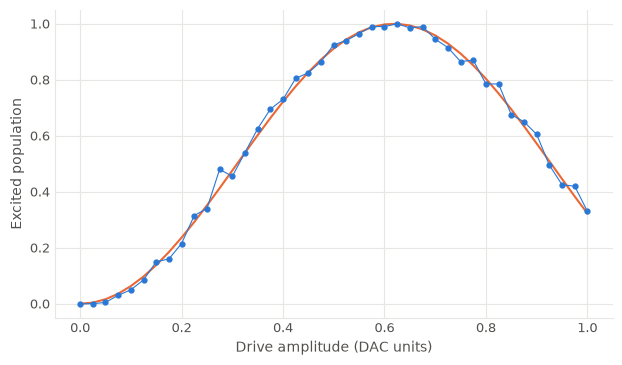

In [37]:
draw("03_rabi")

### The report

The calibration table is the deliverable, and the fitted pulses go out beside it in a `.wfl` library, so the next run loads these numbers from a file instead of from a literal somebody pasted into a script.

The six panels underneath split the work the way every figure in this tutorial has. matplotlib owns the grid, because a layout of six panels follows from nothing a single result knows, and each panel is drawn by the result that owns it into the axes it was handed as `target=`.

quantity              measured        true    error
f_r (GHz)               7.2000      7.2000     0.0%
f_01 (GHz)              4.8500      4.8500     0.0%
a_pi (DAC)              0.6191      0.6200     0.2%
T1 (us)                17.8634     18.0000     0.8%
T2* (us)                8.9410      9.0000     0.7%
detuning (MHz)          0.5002      0.5000     0.0%
T2 echo (us)           15.8509     16.0000     0.9%

artifacts in out/bringup:
  ['01_resonator.qp', '02_qubit.qp', '03_rabi.qp', '04_t1.qp', '05_ramsey.qp', '06_echo.qp', '07_reset.qp', 'calibration.wfl']


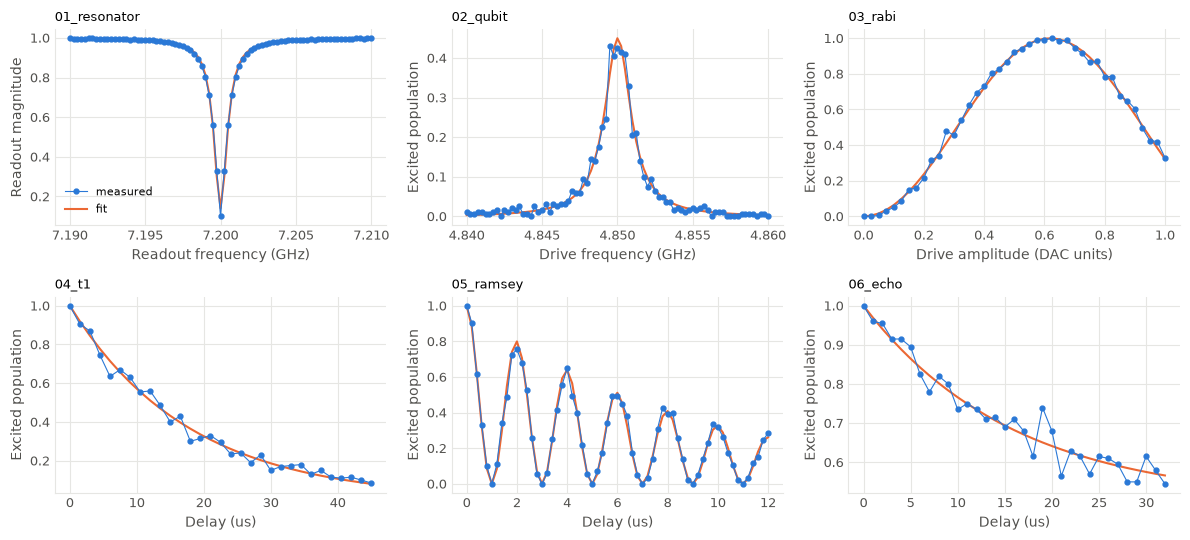

In [38]:
library = qp.WaveformLibrary()
library.set("pi", PI, element="q", idx=0, kind="drive")  # exactly what steps 4 to 6 played
library.set("x90", X90, element="q", idx=0, kind="drive")
library.set("readout", IQPair(Square(0.2, 2000), Square(0.0, 2000)), element="q", kind="readout")
library.set("weights", IQPair(Square(1.0, 2000), Square(1.0, 2000)))
library.save(OUT / "calibration.wfl")

print(f"{'quantity':<18}{'measured':>12}{'true':>12}{'error':>9}")
for name, (measured, truth) in CAL.items():
    print(f"{name:<18}{measured:>12.4f}{truth:>12.4f}{100 * abs(measured - truth) / abs(truth):>8.1f}%")
print(f"\nartifacts in {OUT}:")
print(" ", sorted(p.name for p in OUT.iterdir()))

fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
for ax, name in zip(axes.ravel(), TRACES, strict=True):
    draw(name, target=ax)
    ax.set_title(name, loc="left", fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Recap

- **A waveform is a class and two methods.** `envelope(resolution)` and `get_duration()` are all a `Waveform` subclass owes, and `plot`, `area`, `peak_amplitude`, `rms_amplitude`, `spectrum`, and structural equality arrive off the base class. `qp.register_waveform` puts the shape in the file format and `qp.register_waveform_token` gives a rack a name to refuse it by. A parameter a sweep will bind is annotated `float | qp.Expression` and resolved with `evaluate_or_raise()`.
- **A sweep source is a class and two methods.** `length()` and `values()`, plus the `KIND` and `TOKEN` declarations, and `qp.register_sweep_source` registers the token along with the class.
- **A vendor operation is two classes and four calls.** An `Operation` for the node and a `VendorNamespace` for the method surface, then `register_vendor`, `register_vendor_version`, `register_vendor_operation`, and `register_capability_tokens`. `register_profile` publishes the token bundle a rack reaches by name.
- **Serialization is derived from `__init__`.** All three seams read the constructor signature, so the constructor arguments have to be the object's state.
- **The token makes an extension safe.** A rack that lacks it refuses the program with a named diagnostic and a path, before anything reaches an instrument, and the file stays legal QProgram everywhere else.
- **Entry points make a `.qp` file self-describing.** The `require` line names the vendor, and `loads()` imports the extension that claims it. A vendor nobody claims and a version this install cannot satisfy both fail by name.
- **The `.qp` file is the artifact you keep.** It diffs, it reviews, and `python -m qprogram.lsp check` turns it into a CI job.
- **A platform is six members.** `get_bus_schema`, `get_buses`, `get_parameters`, `get_global_parameters`, `capabilities`, and `execute` are the whole of `PlatformProtocol`, with `validate`, `plan`, and `explain` defaulted and `stream` optional. The reference executor defines what a program's result means, so a vendor compiler has an oracle to be tested against.
- **The capstone recovered f_r, f01, the pi amplitude, T1, T2\*, the detuning, and T2 from simulated data**, wrote a file per step, drew every panel through the result that produced it, and put the fitted pulses in a `.wfl` library.

## Next

The published documentation at qilimanjaro-tech.github.io/qprogram carries the normative material in its Reference section, `docs/reference/qp-format.md` covers the text format, and `src/qprogram/grammar/qp.lark` is the machine-readable grammar. `docs/developer/vendor-extensions.md` walks a vendor package end to end, and `qprogram-qdac` is the smallest complete one worth copying. A seam this notebook had no use for is there too: `qp.register_vendor_block` adds a block keyword with its own indented suite, for a vendor that ships control flow of its own.

One idea to carry forward. The program, the plan, the result, and the calibration are all data, and everything this tutorial did followed from that. A program you can serialize is a program you can diff, review, check in CI, and hand to a different machine. A plan you can print is a performance question you can answer before you spend fridge time on it. A result that carries its own coordinates draws itself and puts a fit on the right axis. A calibration in a file is a number with a provenance rather than a literal somebody remembers typing.